In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os

In [3]:
# 1. DEFINE MODEL ARCHITECTURE (MUST MATCH ORIGINAL)
class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2),
            nn.Conv2d(6, 16, kernel_size=5),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(16 * 5 * 5, 120),
            nn.Tanh(),
            nn.Linear(120, 84),
            nn.Tanh(),
            nn.Linear(84, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [4]:
# 2. LOAD MODEL
print("Loading saved LeNet-5 model...")
model_path = r"D:\Sj\PreThesis\Weeks\Week2\lenet5.pth"

# Load checkpoint
checkpoint = torch.load(model_path, map_location=torch.device('cpu'))

# Create and load model
model = LeNet5(num_classes=10)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()  # Important: set to evaluation mode

print(f"✓ Model loaded!")
print(f"  Accuracy: {checkpoint['test_accuracy']:.2f}%")
print(f"  Epochs: {checkpoint['epochs_trained']}")

Loading saved LeNet-5 model...
✓ Model loaded!
  Accuracy: 98.86%
  Epochs: 10


C:\Users\duong\AppData\Local\Temp\ipykernel_18180\479433906.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=torch.device

In [5]:
# 3. PREPARE DATA (Same transformations as training)
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load a few test samples
test_dataset = torchvision.datasets.MNIST(
    root=r'D:\Sj\PreThesis\Data\Week2',
    train=False,
    download=True,  # Will use cached version if already downloaded
    transform=transform
)

In [6]:
# 4. MAKE PREDICTIONS
print("\nMaking predictions on test samples...")

# Get 5 random test images
indices = np.random.choice(len(test_dataset), 5, replace=False)
test_samples = []
test_labels = []

for idx in indices:
    img, label = test_dataset[idx]
    test_samples.append(img)
    test_labels.append(label)

# Convert to batch
batch = torch.stack(test_samples)  # Shape: [5, 1, 32, 32]

# Make predictions (no gradient calculation)
with torch.no_grad():
    outputs = model(batch)
    _, predictions = torch.max(outputs, 1)


Making predictions on test samples...



Predictions:


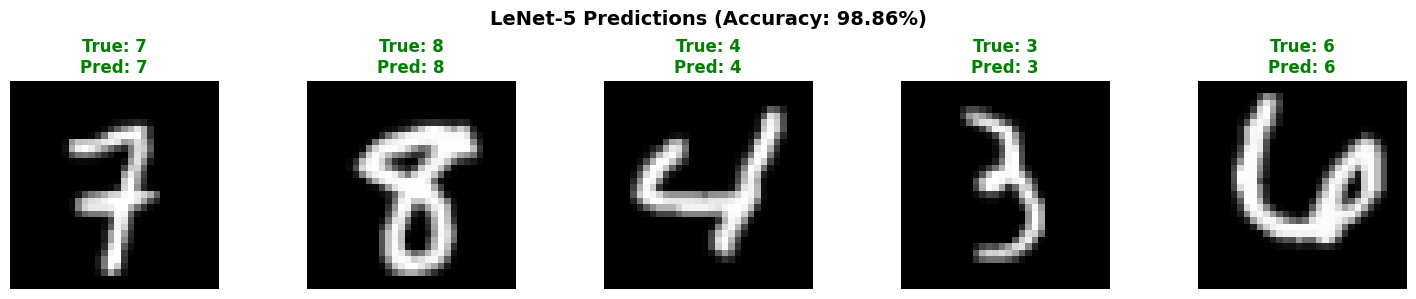

In [7]:
# 5. DISPLAY RESULTS
print("\nPredictions:")
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = test_samples[i].squeeze()  # Remove channel dimension
    axes[i].imshow(img, cmap='gray')
    
    is_correct = (predictions[i].item() == test_labels[i])
    color = 'green' if is_correct else 'red'
    
    axes[i].set_title(f"True: {test_labels[i]}\nPred: {predictions[i].item()}", 
                     color=color, fontweight='bold')
    axes[i].axis('off')

plt.suptitle(f"LeNet-5 Predictions (Accuracy: {checkpoint['test_accuracy']:.2f}%)", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [8]:
# 6. CALCULATE ACCURACY ON A LARGER SET
print("\nCalculating accuracy on 100 test samples...")
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        if total >= 100:  # Only test on first 100 samples
            break
        
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"✓ Accuracy on {total} test samples: {accuracy:.2f}%")
print(f"  (Original training accuracy: {checkpoint['test_accuracy']:.2f}%)")


Calculating accuracy on 100 test samples...
✓ Accuracy on 128 test samples: 100.00%
  (Original training accuracy: 98.86%)
